# **Paper Behind**

Mahapatra, N. C., & Bhuyan, P. (2023). EEG-based classification of imagined digits using a recurrent neural network. *Journal of neural engineering*, *20* (2), 026040.  <br>

[iopscience.iop.org pdf](https://iopscience.iop.org/article/10.1088/1741-2552/acc976/pdf?casa_token=rNBVYYhTFsgAAAAA:WyTHZeT1ipjIxcFYZFytGGMkCQLco4bq9r80L4cQy19c5AfJLR-Ql3syH3hleUx59J5T9y62_QWpGGfczWj0Ac2Lhl5F)


In [ ]:
!pip install PyWavelets
!pip install mne
!pip install autoreject
!pip install pip install mne-icalabel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 38.9 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement install (from versions: none)
ERROR: No matching distribution found for install


In [ ]:
import numpy as np
import numpy.fft as fft
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy import signal
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision
import torchaudio
from torchvision import transforms
import cv2
%matplotlib inline
from utils import MindBigData, GetDataSet, GetDataLoaders, GetDataLoadersEEGImages, GetDataAndPreProcess
import time
import pywt

seed = 123
np.random.seed(seed)
torch.manual_seed(seed)

In [ ]:
from autoreject import AutoReject
from mne.preprocessing import ICA
import mne as mne

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# do it if u have not extraxted zip file before
# download dataset to google drive

# def DownloadDataSet(link, drive_path, colab_path, filename):
    # ! wget -c -P "{drive_path}" "{link}"
    # !unzip "{drive_path}/{filename}" -d "{drive_path}"
    # !cp -r "{drive_path}" "{colab_path}"

In [ ]:
# do it if u have not extraxted zip file before

# link = 'http://www.mindbigdata.com/opendb/MindBigData-EP-v1.0.zip'
# drive_path = '/content/drive/MyDrive/DLProj/data/'
# colab_path = '.'

# DownloadDataSet(link, drive_path, colab_path,"MindBigData-EP-v1.0.zip")

--2025-05-14 05:02:18--  http://www.mindbigdata.com/opendb/MindBigData-EP-v1.0.zip
Resolving www.mindbigdata.com (www.mindbigdata.com)... 150.136.107.169
Connecting to www.mindbigdata.com (www.mindbigdata.com)|150.136.107.169|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://mindbigdata.com/opendb/MindBigData-EP-v1.0.zip [following]
--2025-05-14 05:02:18--  https://mindbigdata.com/opendb/MindBigData-EP-v1.0.zip
Resolving mindbigdata.com (mindbigdata.com)... 150.136.107.169
Connecting to mindbigdata.com (mindbigdata.com)|150.136.107.169|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 427958689 (408M) [application/zip]
Saving to: ‘/content/drive/MyDrive/DLProj/data/MindBigData-EP-v1.0.zip’

MindBigData-EP-v1.0 100%[===================>] 408.13M  35.5MB/s    in 11s     

2025-05-14 05:02:30 (36.1 MB/s) - ‘/content/drive/MyDrive/DLProj/data/MindBigData-EP-v1.0.zip’ saved [427958689/427958689]

Archive:  /content/drive/MyDrive/DL

In [ ]:
# do it if u have not extraxted zip file before
x, y = GetDataAndPreProcess(input_file="/content/drive/MyDrive/113-2/BCI/EP1.01.txt", samples_per_digit=6500)

[6466, 6324, 6443, 6500, 6304, 6500, 6478, 6293, 6494, 6500]


In [ ]:
train_loader, valid_loader, test_loader = GetDataLoaders(x, y, batch_size=64)

## **Initial Display** <br>
Make sure the data is loaded

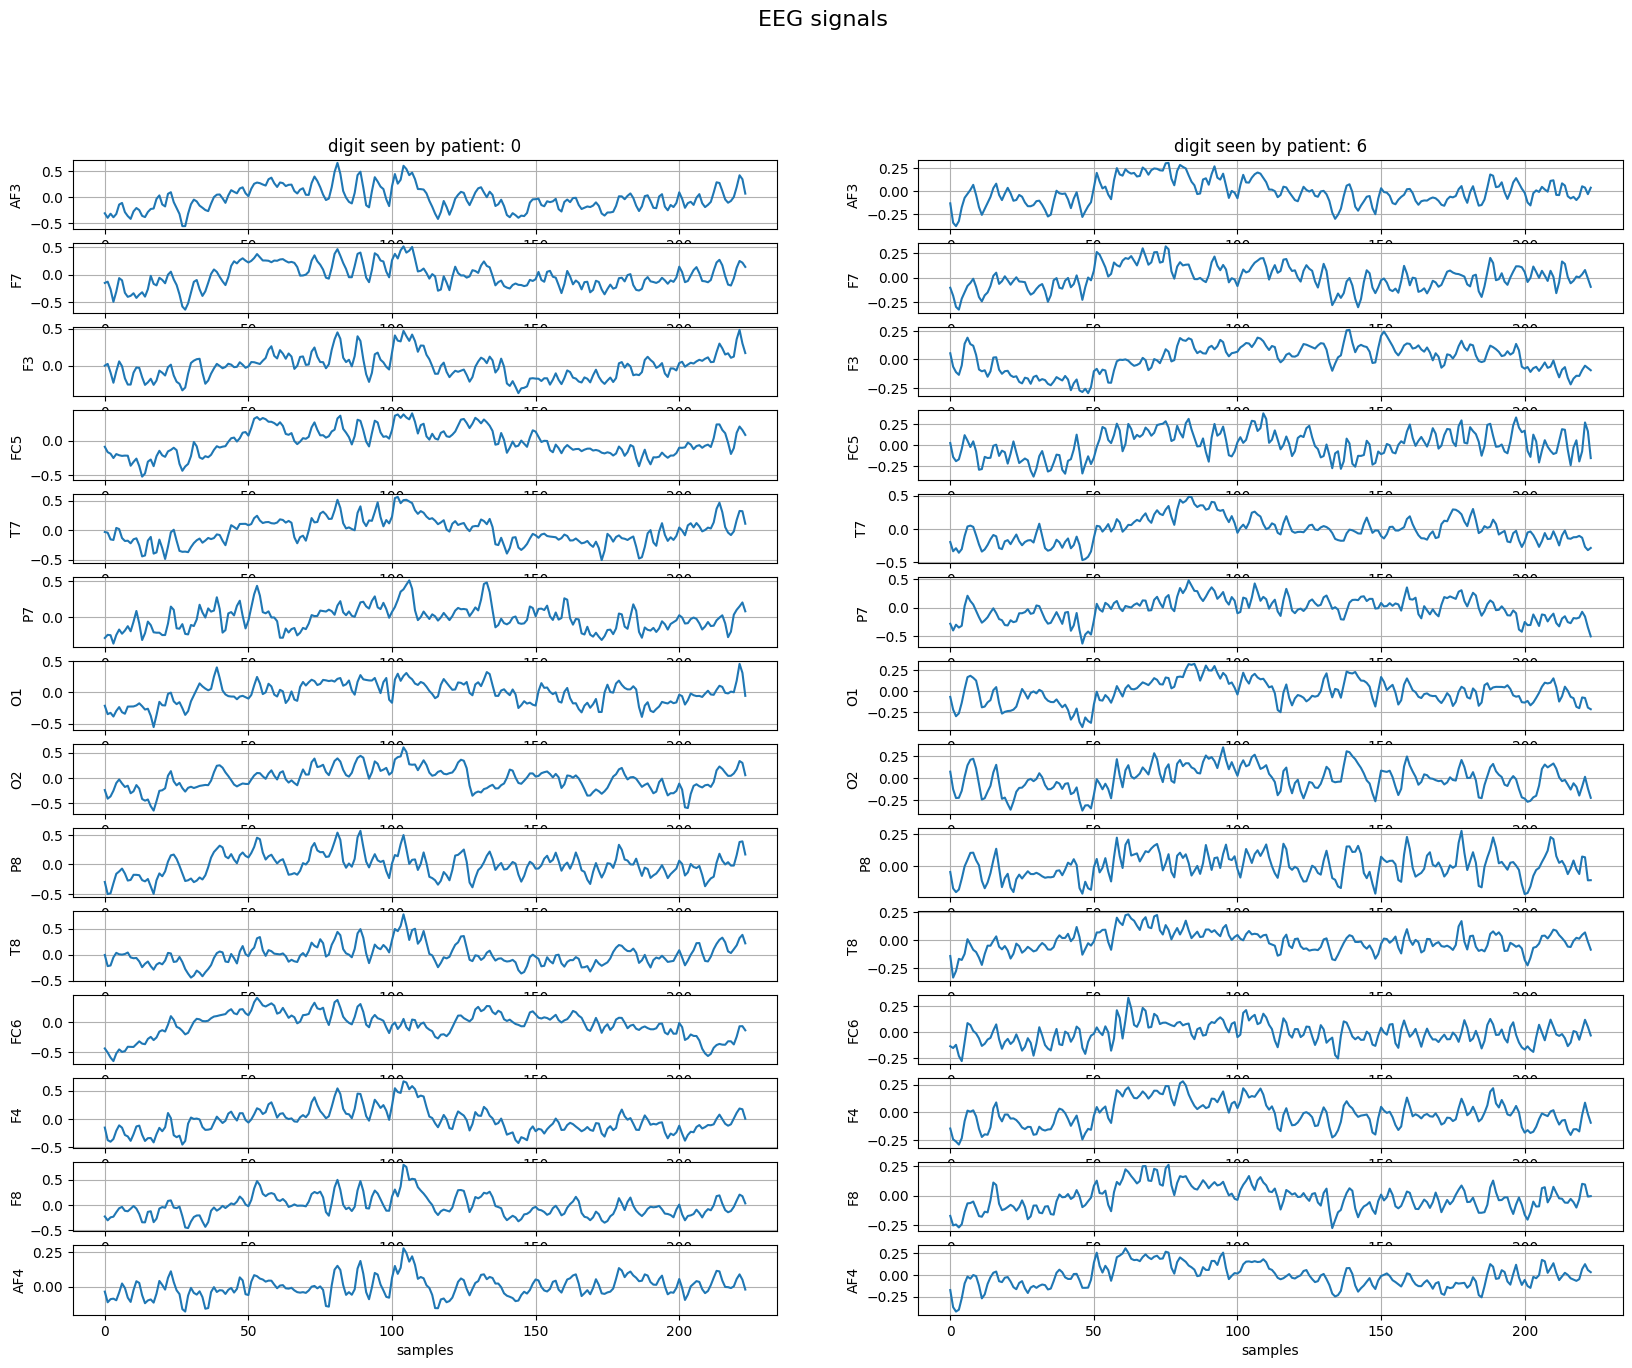

In [ ]:
# Display 2 signals with their labels
# replace .next() with next() in Python3
data_iter = iter(train_loader)
inputs, labels = next(data_iter)
EEGChannel = ["AF3", "F7", "F3", "FC5", "T7", "P7", "O1", "O2", "P8", "T8", "FC6", "F4", "F8", "AF4"]

fig = plt.figure(figsize=(20, 15))
fig.suptitle('EEG signals', fontsize=16)
for i in range(2):
    for j in range(14):
        ax = fig.add_subplot(14, 2, i + 1 + 2 * j)
        if (j == 0):
            ax.set_title(
                'digit seen by patient: ' + str(labels[i].item()))  # .item() gets the value contained in a tensor
        ax.plot(inputs[i][j])
        ax.set_xlabel('samples')
        ax.set_ylabel(EEGChannel[j])
        ax.grid()

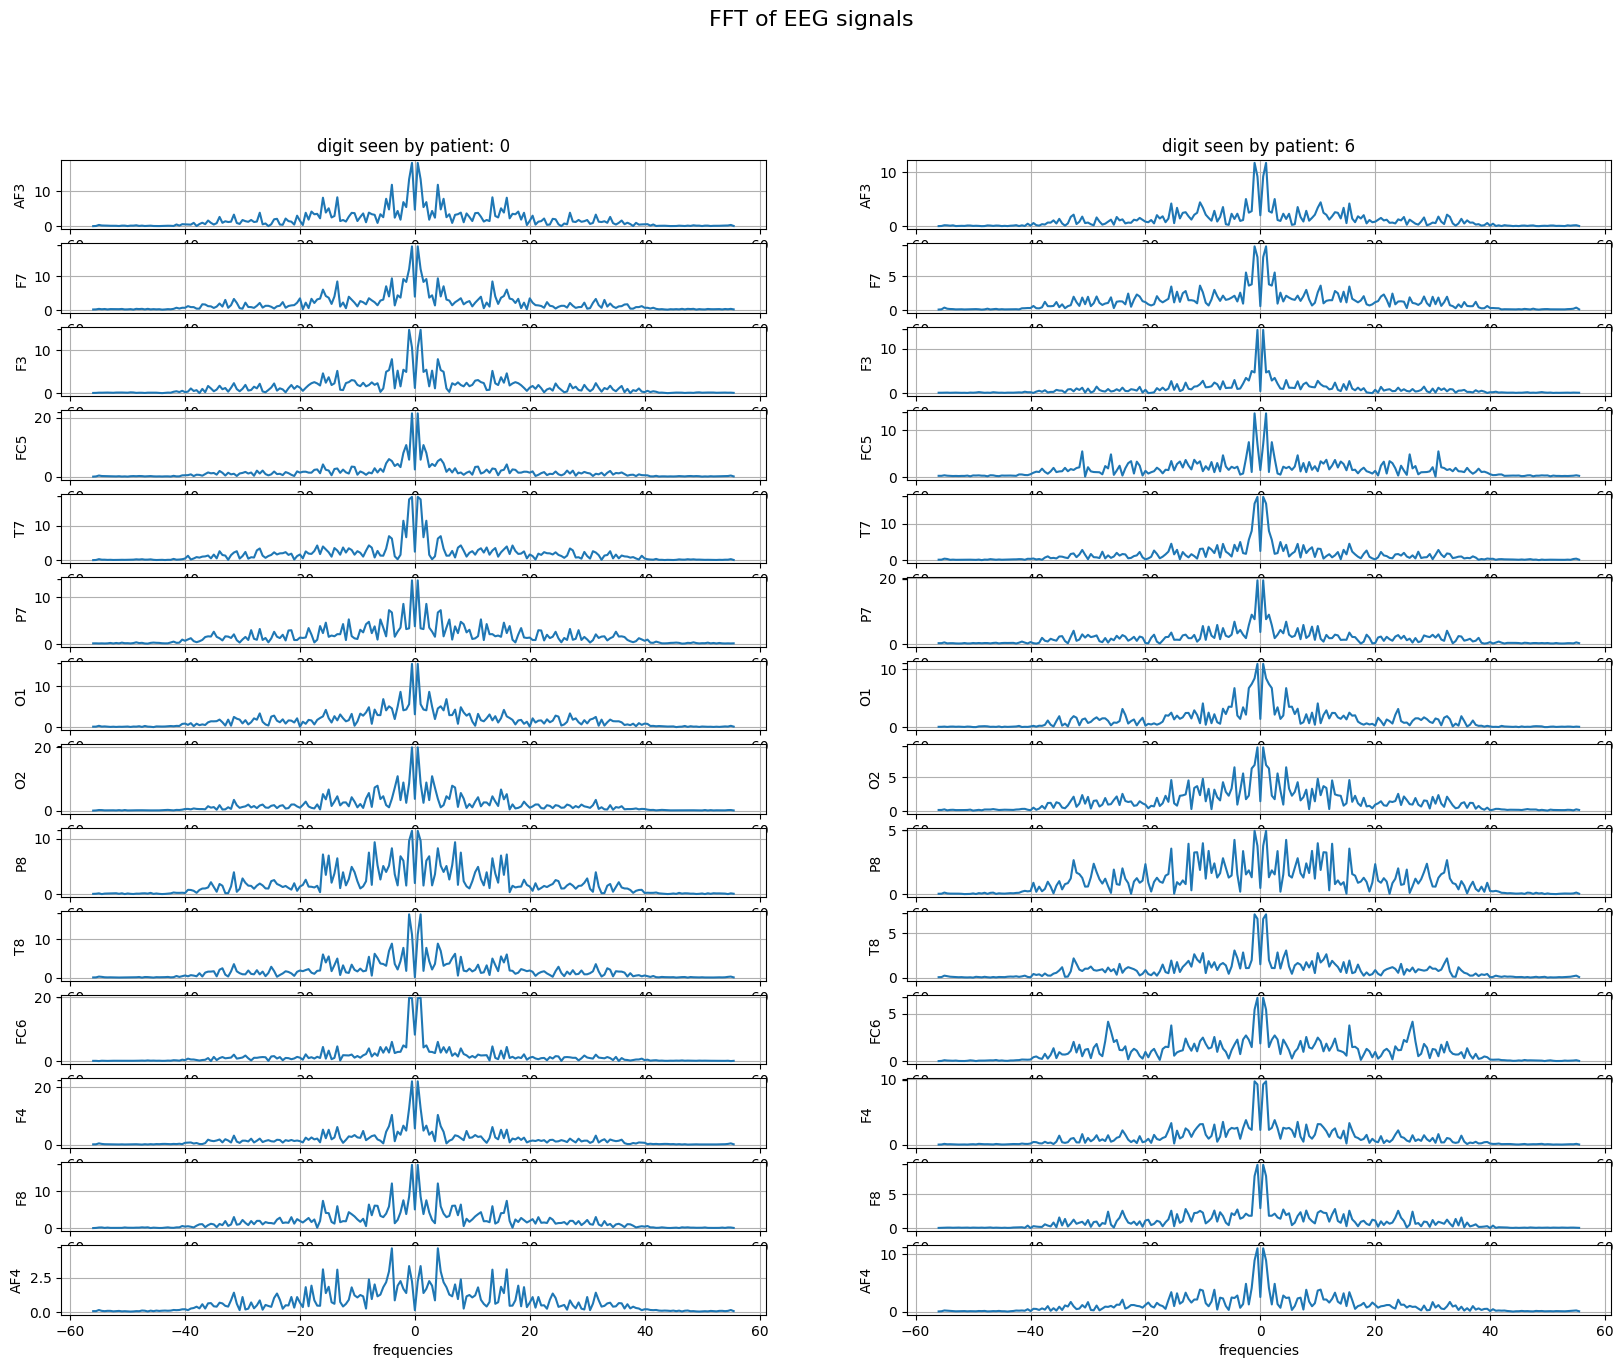

In [ ]:
# Display 2 FFT of signals with their labels
f = np.arange(-112, 112) * 0.5
fig = plt.figure(figsize=(20, 15))
fig.suptitle('FFT of EEG signals', fontsize=16)
for i in range(2):
    for j in range(14):
        ax = fig.add_subplot(14, 2, i + 1 + 2 * j)
        if (j == 0):
            ax.set_title(
                'digit seen by patient: ' + str(labels[i].item()))  # .item() gets the value contained in a tensor
        ax.plot(f, abs(fft.fftshift(fft.fft(inputs[i][j]))))
        ax.set_xlabel('frequencies')
        ax.set_ylabel(EEGChannel[j])
        ax.grid()

## **Separate EPOC & MUSE**
**EPOC channels: 14** <br>
AF4, F4, F8, FC6, O2, P8, T8, T7, P7, O1, FC5, F7, F3 and AF3 <br>
**MUSE channels: 4** <br>
TP9, FP1, FP2 and
TP10 <br>



In [ ]:
# Define the channel names for each device
# EPOC_CHANNELS = ["AF4", "F4", "F8", "FC6", "O2", "P8", "T8", "T7", "P7", "O1", "FC5", "F7", "F3", "AF3"]
# MUSE_CHANNELS = ["TP9", "FP1", "FP2", "TP10"]

In [ ]:
# def separate_eeg_datasets(X, channel_names):
    # """
    # Separate EPOC and MUSE data based on channel names.

    # Parameters:
    # - X: EEG data with shape (n_samples, n_channels, n_timepoints)
    # - channel_names: List of channel names corresponding to the channel dimension in X

    # Returns:
    # - epoc_data: Data from EPOC channels only
    # - muse_data: Data from MUSE channels only
    # - epoc_indices: Indices of EPOC channels in the original data
    # - muse_indices: Indices of MUSE channels in the original data
    # """
    # # Find indices of EPOC and MUSE channels in the provided channel list
    # epoc_indices = [i for i, ch in enumerate(channel_names) if ch in EPOC_CHANNELS]
    # muse_indices = [i for i, ch in enumerate(channel_names) if ch in MUSE_CHANNELS]

    # # Extract data for each device type
    # epoc_data = X[:, epoc_indices, :]
    # muse_data = X[:, muse_indices, :]

    # print(f"EPOC data shape: {epoc_data.shape}")
    # print(f"MUSE data shape: {muse_data.shape}")
    # print(f"EPOC channels used: {[channel_names[i] for i in epoc_indices]}")
    # print(f"MUSE channels used: {[channel_names[i] for i in muse_indices]}")

    # return epoc_data, muse_data, epoc_indices, muse_indices

In [ ]:
# Separate datasets
# epoc_data, muse_data, epoc_indices, muse_indices = separate_eeg_datasets(x)

# print(f"EPOC dataset shape: {epoc_data.shape}")
# print(f"MUSE dataset shape: {muse_data.shape}")

## **Define Model**
define utility classes

### **ModelTrainer Pipeline**
calculate_accuracy -> train_and_plot

#### **train_and_plot**





In [ ]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=256, output_size=10, num_layers=4, dropout=0.4):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Define GRU layers dynamically based on num_layers
        self.gru_layers = nn.ModuleList()
        # First layer: input_size to hidden_size
        self.gru_layers.append(nn.GRU(input_size, hidden_size, num_layers=1, batch_first=True, bidirectional=True))
        # Subsequent layers: hidden_size * 2 (bidirectional) to hidden_size
        for _ in range(num_layers - 1):
            self.gru_layers.append(nn.GRU(hidden_size * 2, hidden_size, num_layers=1, batch_first=True, bidirectional=True))

        # Dropout layer
        self.dropout = nn.Dropout(dropout)

        # Flatten and Dense layers
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(hidden_size * 2, 128)  # Adjusted for bidirectional output of the last time step
        self.fc2 = nn.Linear(128, output_size)

        # Activation
        self.relu = nn.ReLU()

    def forward(self, x):
        out = x
        for i, gru in enumerate(self.gru_layers):
            # Initialize hidden state for each GRU layer
            h0 = torch.zeros(2, x.size(0), self.hidden_size).to(x.device)  # 2 for bidirectional, 1 layer per GRU
            out, _ = gru(out, h0)
            out = self.dropout(out)

        # Flatten and Dense layers
        out = self.flatten(out[:, -1, :])  # Take the last time step
        out = self.relu(self.fc1(out))
        out = self.fc2(out)

        return out

    def save_model(self, path="enhanced_model.pth"):
        torch.save(self.state_dict(), path)
        print(f"Model saved to {path}")

In [ ]:
# Early Stopping Class
class EarlyStopping:
    def __init__(self, patience=10, verbose=False, delta=0.0):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_loss = float('inf')

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.best_loss = val_loss
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_loss = val_loss
            self.counter = 0

In [ ]:
# Data Preprocessing Class
class DataPreprocessor:
    def __init__(self, expected_channels=14, expected_seq_length=224):
        self.expected_channels = expected_channels
        self.expected_seq_length = expected_seq_length

    def preprocess(self, x, y):
        # Check the shape of x
        print(f"Shape of x before preprocessing: {x.shape}")

        # Preprocess data to ensure correct shape
        if x.ndim == 3 and x.shape[1] == self.expected_channels and x.shape[2] == self.expected_seq_length:
            x = np.transpose(x, (0, 2, 1))  # Reshape from (batch_size, 14, 224) to (batch_size, 224, 14)
        elif x.ndim == 3 and x.shape[2] != self.expected_channels:
            raise ValueError(f"Expected input_size={self.expected_channels}, got {x.shape[2]}")

        print(f"Shape of x after preprocessing: {x.shape}")

        # Convert to tensors
        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.long)

        return x, y

In [ ]:
class EEGSignalPreprocessor:
    def __init__(self, expected_channels=14, expected_seq_length=224, sampling_rate=128):
        self.expected_channels = expected_channels
        self.expected_seq_length = expected_seq_length
        self.sampling_rate = sampling_rate
        # use standard 10-20 systems
        self.ch_names = ["AF3", "F7", "F3", "FC5", "T7", "P7", "O1", "O2", "P8", "T8", "FC6", "F4", "F8", "AF4"]
        self.montage_name = 'standard_1020'

    def filtering(self, x):
        from scipy.signal import butter, filtfilt

        def butter_bandpass(lowcut, highcut, fs, order=4):
            nyq = 0.5 * fs
            low = lowcut / nyq
            high = highcut / nyq
            b, a = butter(order, [low, high], btype='band')
            return b, a

        print("Applying bandpass filter (0.5-40 Hz)...")
        filtered = np.zeros_like(x)
        b, a = butter_bandpass(0.5, 40, self.sampling_rate)

        for i in range(x.shape[0]):  # batch
            for ch in range(x.shape[1]):  # channels
                filtered[i, ch, :] = filtfilt(b, a, x[i, ch, :])

        return filtered

    def preprocess_autoreject_ica(self, x_filtered, max_samples=None, save_path=None):
        """
        Preprocess EEG with AutoReject and ICA for artifact removal.
        """
        n_samples, n_channels, n_times = x_filtered.shape

        if max_samples is not None:
            x_filtered = x_filtered[:max_samples]
            n_samples = x_filtered.shape[0]

        info = mne.create_info(self.ch_names, sfreq=self.sampling_rate, ch_types='eeg')
        montage = mne.channels.make_standard_montage(self.montage_name)
        info.set_montage(montage)

        epochs = mne.EpochsArray(x_filtered, info)

        # --- AutoReject ---
        ar = AutoReject(cv=2, n_interpolate=[1], consensus=[0.5], verbose=False)
        epochs_clean, reject_log = ar.fit_transform(epochs, return_log=True)

        # --- Downsample for ICA ---
        epochs_down = epochs_clean.copy().resample(64)

        # --- ICA ---
        ica = ICA(n_components=0.95, random_state=42, max_iter='auto')
        ica.fit(epochs_down)

        # --- Basic artifact detection (using variance-based component selection) ---
        ica_scores = ica.score_sources(epochs_down, method='variance')
        exclude = [i for i, score in enumerate(ica_scores) if abs(score) > np.std(ica_scores) * 2]
        print(f"Excluding {len(exclude)} artifact components based on variance: {exclude}")

        # --- Apply ICA to full-resolution data, excluding artifacts ---
        epochs_ica = ica.apply(epochs_clean, exclude=exclude)

        cleaned_data = epochs_ica.get_data()

        if save_path:
            np.save(save_path, cleaned_data)
            print(f"✅ Cleaned EEG saved to: {save_path}")

        return cleaned_data, reject_log

    def discrete_wavelet_transform(self, x):
        print("Applying 3-level Discrete Wavelet Transform (DWT)...")
        transformed = []
        for i in range(x.shape[0]):  # batch
            sample = []
            for ch in range(x.shape[1]):  # channels
                signal = x[i, ch, :]
                coeffs = pywt.wavedec(signal, 'db4', level=3)

                rec_cD1 = pywt.upcoef('d', coeffs[-1], 'db4', level=1, take=len(signal))
                rec_cD2 = pywt.upcoef('d', coeffs[-2], 'db4', level=2, take=len(signal))
                rec_cD3 = pywt.upcoef('d', coeffs[-3], 'db4', level=3, take=len(signal))
                rec_cA3 = pywt.upcoef('a', coeffs[0], 'db4', level=3, take=len(signal))

                band_stack = np.stack([rec_cD1, rec_cD2, rec_cD3, rec_cA3], axis=0)
                sample.append(band_stack)

            transformed.append(np.stack(sample, axis=0))

        return np.array(transformed)

    def normalization(self, x):
        print("Applying z-score normalization...")
        mean = np.mean(x, axis=2, keepdims=True)
        std = np.std(x, axis=2, keepdims=True)
        std[std == 0] = 1e-10  # Avoid division by zero
        return (x - mean) / std

    def preprocess(self, x, y, max_samples=None, save_path=None):
        print(f"Shape of x before preprocessing: {x.shape}")

        # Apply preprocessing pipeline
        x = self.filtering(x)
        x, reject_log = self.preprocess_autoreject_ica(x, max_samples, save_path)
        x = self.discrete_wavelet_transform(x)
        x = self.normalization(x)

        # Adjust shape for DWT output (batch_size, channels, 4, seq_len)
        if x.ndim == 4 and x.shape[1] == self.expected_channels and x.shape[3] == self.expected_seq_length:
            x = np.transpose(x, (0, 3, 1, 2))  # Reshape to (batch_size, seq_len, channels, 4)
        else:
            raise ValueError(f"Unexpected shape after preprocessing: {x.shape}")

        print(f"Shape of x after preprocessing: {x.shape}")

        # Convert to tensors
        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.long)

        return x, y, reject_log

In [ ]:
# Plotting and Training Class
class ModelTrainer:
    def __init__(self, model, device):
        self.model = model
        self.device = device

    def calculate_accuracy(self, loader, criterion):
        self.model.eval()
        total_correct = 0
        total_images = 0
        running_loss = 0.0
        confusion_matrix = torch.zeros(10, 10)

        with torch.no_grad():
            for data in loader:
                inputs, labels = data
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = self.model(inputs)
                loss = criterion(outputs, labels)
                running_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total_images += labels.size(0)
                total_correct += (predicted == labels).sum().item()

                for t, p in zip(labels.view(-1), predicted.view(-1)):
                    confusion_matrix[t.long(), p.long()] += 1

        accuracy = total_correct / total_images * 100
        avg_loss = running_loss / len(loader)
        return accuracy, confusion_matrix, avg_loss

    def train_and_plot(self, x, y):
        # Hyperparameters
        learning_rate = 0.06
        epochs = 200
        weight_decay = 9e-4
        batch_size = 215

        # Preprocess data using DataPreprocessor
        preprocessor = EEGSignalPreprocessor(expected_channels=14, expected_seq_length=224)
        x, y = preprocessor.preprocess(x, y)

        # Get data loaders (assuming GetDataLoaders is defined)
        train_loader, valid_loader, test_loader = GetDataLoaders(x, y, batch_size)

        # Loss criterion and optimizer
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.SGD(self.model.parameters(), lr=learning_rate, weight_decay=weight_decay)

        # Learning Rate Scheduler
        scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

        # Early Stopping
        early_stopping = EarlyStopping(delta=0.00, patience=10, verbose=True)

        # Training loop
        train_losses = []
        valid_losses = []

        for epoch in range(1, epochs + 1):
            self.model.train()
            running_loss = 0.0
            total_correct = 0
            total_images = 0
            epoch_time = time.time()

            for train_data in train_loader:
                inputs, labels = train_data
                inputs, labels = inputs.to(self.device), labels.to(self.device)

                outputs = self.model(inputs)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()
                optimizer.zero_grad()

                _, predicted = torch.max(outputs.data, 1)
                total_images += labels.size(0)
                total_correct += (predicted == labels).sum().item()
                running_loss += loss.item()

            running_loss /= len(train_loader)
            train_losses.append(running_loss)

            train_accuracy = total_correct / total_images * 100
            valid_accuracy, _, valid_loss = self.calculate_accuracy(valid_loader, criterion)
            valid_losses.append(valid_loss)

            log = f"Epoch: {epoch} | Train Loss: {running_loss:.4f} | Training accuracy: {train_accuracy:.3f}% | Validation Loss: {valid_loss:.3f} | Validation accuracy: {valid_accuracy:.3f}% | "
            epoch_time = time.time() - epoch_time
            log += f"Epoch Time: {epoch_time:.2f} secs"
            print(log)

            scheduler.step(valid_loss)
            early_stopping(valid_loss, self.model)
            if early_stopping.early_stop:
                break

        print('==> Finished Training ...')

        # Test accuracy and confusion matrix
        test_accuracy, confusion_matrix, _ = self.calculate_accuracy(test_loader, criterion)
        print(f"test accuracy: {test_accuracy:.3f}%")

        # Plot confusion matrix
        plt.figure(figsize=(8, 6))
        plt.matshow(confusion_matrix, aspect='auto', vmin=0, vmax=1000, cmap=plt.get_cmap('Blues'))
        plt.ylabel('Actual Category')
        plt.yticks(range(10), range(10))
        plt.xlabel('Predicted Category')
        plt.xticks(range(10), range(10))
        plt.savefig('confusion_matrix.png')

        # Plot loss curves
        plt.figure(figsize=(8, 6))
        plt.plot(train_losses, label='Train Loss')
        plt.plot(valid_losses, label='Validation Loss')
        plt.legend()
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Loss')
        plt.savefig('loss_curves.png')

## **Run Model**
run the defined classes

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
model = GRUModel(input_size=14, hidden_size=64, output_size=10).to(device)
trainer = ModelTrainer(model, device)

In [ ]:
trainer.train_and_plot(x, y)

Shape of x before preprocessing: (64302, 14, 224)
Applying bandpass filter (0.5-40 Hz)...
Not setting metadata
64302 matching events found
No baseline correction applied
0 projection items activated


In [ ]:
model.save_model("gru_model.pth")

# Compile with Optuna

In [ ]:
# !pip install optuna
# import optuna

In [ ]:
# def compile_model(trial):
#     # hyper-parameters
#     epochs = 200
#     learning_rate = trial.suggest_float("learning_rate", 1e-2, 1e-1, log=True) # log=True, will use log scale
#     weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True) # log=True, will use log scale
#     batch_size = trial.suggest_int("batch_size", 64, 256) # batch_size will be between 64 and 256

#     # Generate the model
#     model = CNN(
#         num_channel = 14,
#         num_classes = 10,
#         signal_length = 224,
#         kernel_window_eeg = 32,
#         filters_n1 = 8,
#     ).to(device)

#     # load data
#     train_loader, valid_loader, test_loader = GetDataLoaders(x, y, batch_size=batch_size)

#     # loss criterion
#     criterion = nn.CrossEntropyLoss()

#     # optimizer - SGD, Adam, RMSProp...
#     optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "RMSprop", "SGD"])
#     optimizer = getattr(optim, optimizer_name)(model.parameters(), lr=learning_rate,
#                                                weight_decay=weight_decay)

#     # Learning Rate Scheduler
#     scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=50,
#                                   verbose=True)

#     # Early Stopping
#     early_stopping = EarlyStopping(delta=0.00, patience=10, verbose=True)

#     # training loop
#     train_losses = []
#     valid_losses = []
#     for epoch in range(1, epochs + 1):
#         model.train() # put in training mode
#         running_loss = 0.0
#         total_correct = 0
#         total_images = 0
#         epoch_time = time.time()
#         for train_data in train_loader:
#             # get the inputs
#             inputs, labels = train_data
#             # send them to device
#             inputs = inputs.to(device)
#             labels = labels.to(device)

#             # forward + backward + optimize
#             outputs = model(inputs) # forward pass
#             loss = criterion(outputs, labels) # calculate the loss

#             # always the same 3 steps
#             loss.backward() # backpropagation
#             optimizer.step() # update parameters
#             optimizer.zero_grad() # zero the parameter gradients

#             # calc accuracy
#             _, predicted = torch.max(outputs.data, 1)
#             total_images += labels.size(0)
#             total_correct += (predicted == labels).sum().item()

#             # print statistics
#             running_loss += loss.data.item()

#         # Normalizing the loss by the total number of train batches
#         running_loss /= len(train_loader)
#         train_losses.append(running_loss)

#         # Calculate training and validation set accuracy of the existing model
#         train_accuracy = total_correct / total_images * 100
#         valid_accuracy, _, valid_loss = calculate_accuracy(model, valid_loader, device, criterion)
#         valid_losses.append(valid_loss)

#         log = "Epoch: {} | Train Loss: {:.4f} | Training accuracy: {:.3f}% | Validation Loss: {:.3f} | Validation accuracy: {:.3f}% | ".format(epoch
#         , running_loss, train_accuracy, valid_loss, valid_accuracy)
#         epoch_time = time.time() - epoch_time
#         log += "Epoch Time: {:.2f} secs".format(epoch_time)
#         print(log)

#         # accuracy is used to track down a plateau
#         scheduler.step(valid_accuracy)

#         # Early Stopping
#         early_stopping(valid_loss, model)
#         if early_stopping.early_stop:
#             break

#         # report back to Optuna how far it is (epoch-wise) into the trial and how
#         # well it is doing (validation accuracy)
#         trial.report(valid_accuracy, epoch)

#         # then, Optuna can decide if the trial should be pruned
#         # Handle pruning based on the intermediate value.
#         if trial.should_prune():
#             raise optuna.exceptions.TrialPruned()

#     print('==> Finished Training ...')

#     # print loss curves
#     plt.plot(train_losses, label='Train Loss')
#     plt.plot(valid_losses, label='Validation Loss')
#     plt.legend()
#     plt.xlabel('Epochs')
#     plt.ylabel('Loss')
#     plt.title('Loss')

#     # calculate accuracy and confusion matrix
#     test_accuracy, confusion_matrix, _ = calculate_accuracy(model, test_loader, device, criterion)
#     print("test accuracy: {:.3f}%".format(test_accuracy))

#     # plot confusion matrix
#     fig, ax = plt.subplots(1,1,figsize=(8,6))
#     ax.matshow(confusion_matrix, aspect='auto', vmin=0, vmax=1000, cmap=plt.get_cmap('Blues'))
#     plt.ylabel('Actual Category')
#     plt.yticks(range(10), range(10))
#     plt.xlabel('Predicted Category')
#     plt.xticks(range(10), range(10))
#     plt.show()

#     return valid_accuracy

In [ ]:
# # Compile with Optuna
# sampler = optuna.samplers.TPESampler()
# study = optuna.create_study(study_name="EEG-CNN", direction="maximize", sampler=sampler)
# study.optimize(compile_model, n_trials=2)
# pruned_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
# complete_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
# print("Study statistics: ")
# print(" Number of finished trials: ", len(study.trials))
# print(" Number of pruned trials: ", len(pruned_trials))
# print(" Number of complete trials: ", len(complete_trials))
# print("Best trial:")
# trial = study.best_trial
# print(" Value: ", trial.value)
# print(" Params: ")
# for key, value in trial.params.items():
#  print(" {}: {}".format(key, value))


In [ ]:
#  optuna.visualization.plot_param_importances(study)